In [ ]:
from common import *
from collections import defaultdict
from uncertainties import ufloat
from scipy import stats
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import seaborn as sns

get(
    "machinable.index",
    "./index",
).__enter__()


machinable.index [e97588]

# Surrogate optimization vs. baselines

In [6]:
_ca1_sopt_baseline = get("interface._ca1_sopt_baseline")

globus_download(_ca1_sopt_baseline)

numprocs=1


In [ ]:
baseline_hvs = defaultdict(dict)
nos_hv = defaultdict(list)
igds = defaultdict(dict)
nadirs = {}

def _name(experiment):
    n = experiment.label().split("_neuron::")[-1][2:].split("/")[0].replace("joint-", "")
    if 'o' in n:
        n += '-' + experiment.config.dopt_params.surrogate_custom_training_kwargs.backbone
    return n

for p in _ca1_sopt_baseline.populations():
    experiments = _ca1_sopt_baseline.components.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    )
    nadir = nadirs[p] = fronts_nadir(experiments)
    tracking = {"interfaces": []}

    for experiment in experiments:
        model_name = _name(experiment)
        
        epoch_ranges = experiment.epoch_ranges(from_zero=True)

        if model_name == "-":
            tracking["interfaces"].append(experiment)
            continue
        
        if model_name == "gpr":
            tracking["ranges"] = epoch_ranges
        
        baseline_hvs[p].setdefault(model_name, {})
        for epoch, region in enumerate(epoch_ranges):
            baseline_hvs[p][model_name].setdefault(epoch, [])
            hv = experiment.norm_hv_region(nadir, region)
            baseline_hvs[p][model_name][epoch].append(hv)
    
    # backfill eval-normalized baseline
    baseline_hvs[p]["baseline"] = {}
    for epoch, region in enumerate(tracking["ranges"]):
        baseline_hvs[p]["baseline"][epoch] = [
            i.norm_hv_region(nadir, region) for i in tracking["interfaces"]
        ]
        
    # compute nos hv after 25 epochs
    for i in tracking["interfaces"]:
        nos_hv[p + '10'].append(i.norm_hv_region(nadir,i.epoch_ranges(from_zero=True)[10]))
        nos_hv[p].append(i.norm_hv(nadir))
        
    # compute igds
    for experiment in experiments:
        model_name = _name(experiment)
        igds[p][model_name] = [
            experiment.igd(i) for i in tracking["interfaces"]
        ]


In [ ]:
initial_samples = {
    p: _ca1_sopt_baseline.components.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    ).first().num_initial_samples for p in _ca1_sopt_baseline.populations()
}

{'SCA': 1500, 'BS': 1200, 'NGFC': 1300, 'OLM': 1200}

In [178]:
stash("figure3-nos_hv", nos_hv)
stash("figure3-nadirs", nadirs)
stash("figure3-baseline_hvs", baseline_hvs)
stash("figure3-initial_samples", initial_samples)

In [ ]:
nadirs = restore("figure3-nadirs")
nos_hv = restore("figure3-nos_hv")
baseline_hvs = restore("figure3-baseline_hvs")
initial_samples = restore("figure3-initial_samples")

/tmp/ipykernel_3402974/149817974.py:91: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


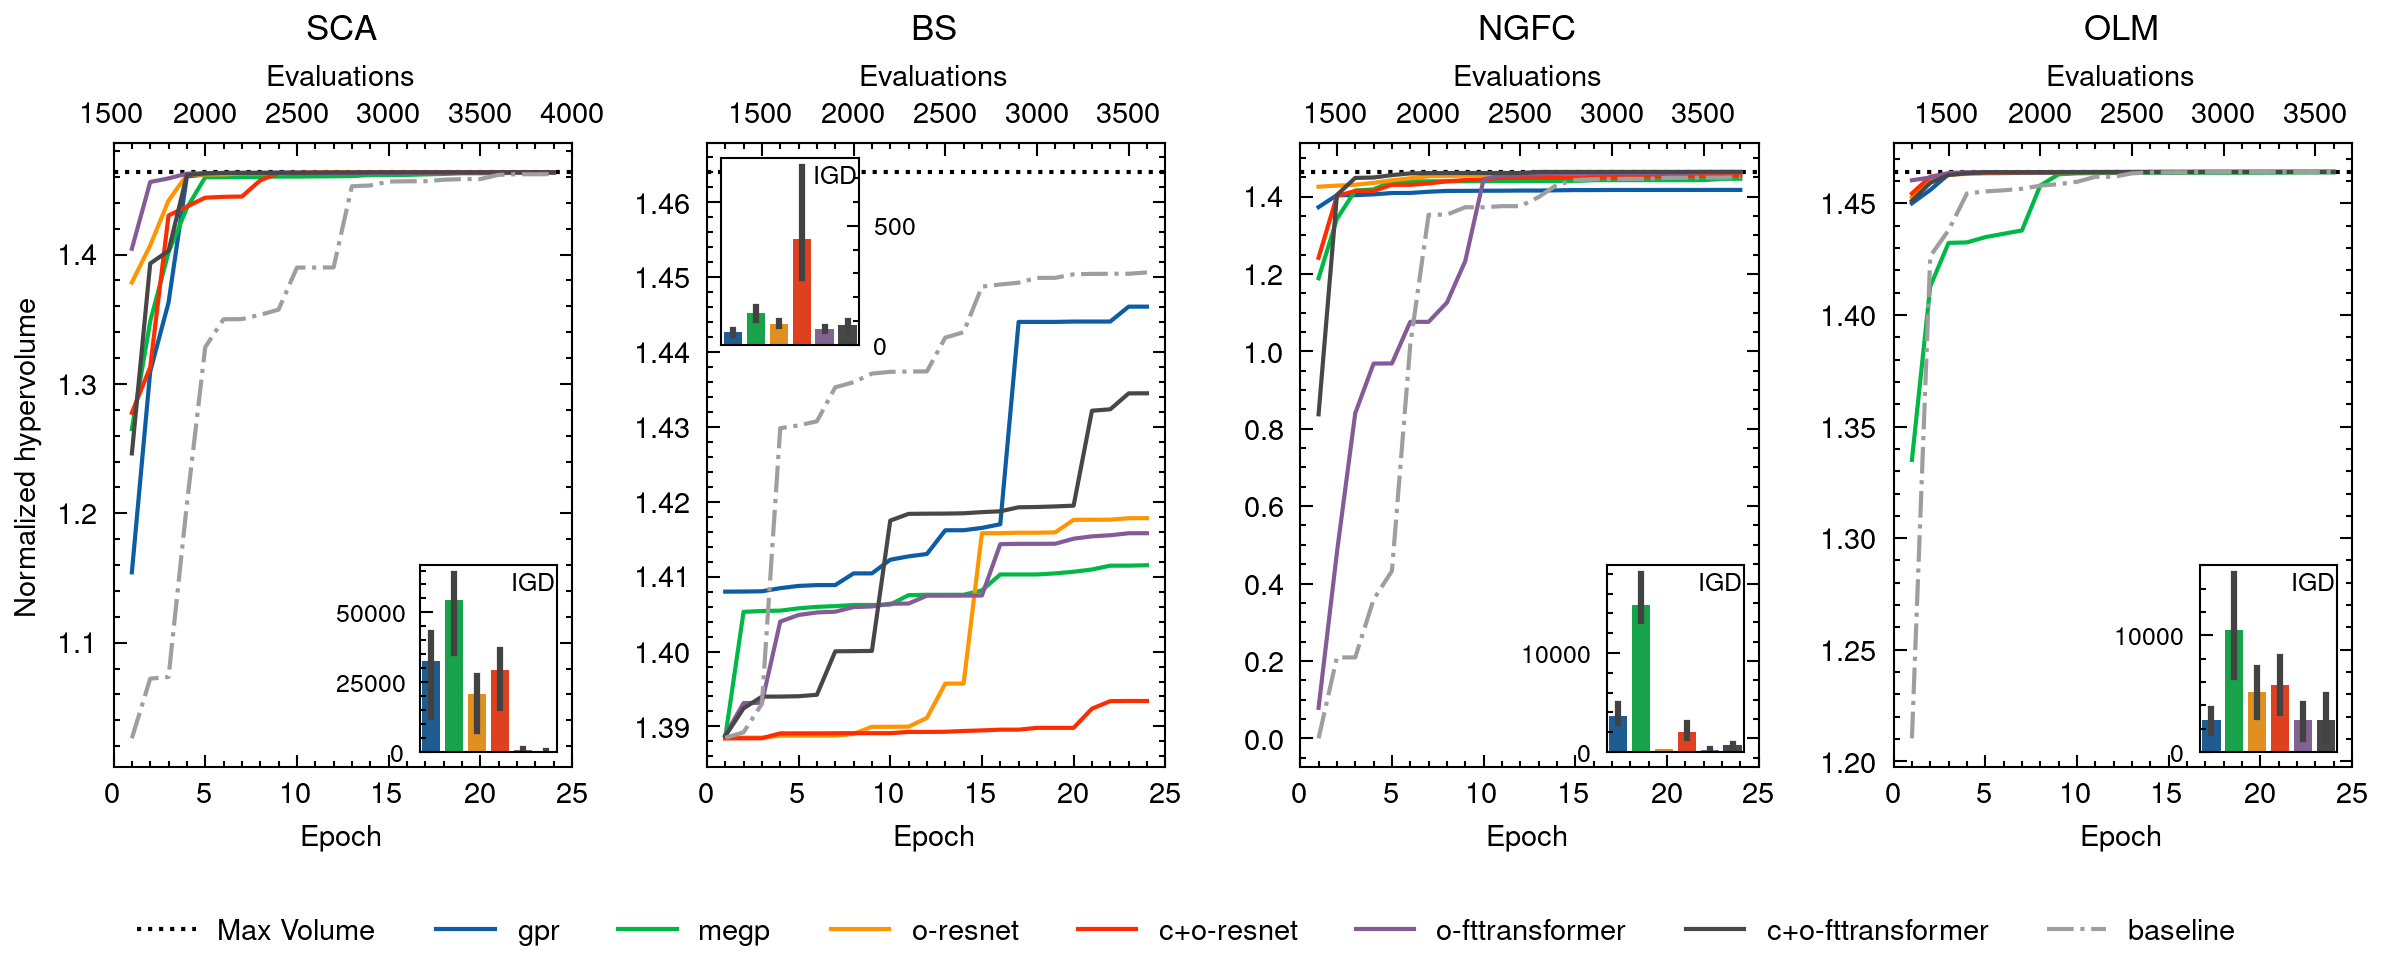

In [180]:
plt.rcParams['xtick.top'] = False
#plt.rcParams['axes.spines.top'] = False

fig, axs = plt.subplots(1, len(baseline_hvs), figsize=(8, 3), sharey=False)

for ax, (p, models) in zip(axs.flatten(), baseline_hvs.items()):
    nos_mean = np.mean(nos_hv[p + '10'])
    nos_err = stats.sem(nos_hv[p + '10'])
    
    ax.axhline(y=1.1**4, color="black", linestyle=":", label="Max Volume")
    
    # determine epoch when converged
    converged = {}
    for i, (model_name, epoch_hvs) in enumerate(models.items()):
        for epoch, hvs in epoch_hvs.items():
            if epoch > 1 and np.mean(hvs) >= 0.99 * nos_mean: #stats.ttest_ind(nos_hv[p], hvs).pvalue > 0.05: # np.abs(np.mean(nos_hv[p]) - np.mean(hvs)) < 0.01: 
                converged[model_name] = epoch
                break
    
    for i, (model_name, epoch_hvs) in enumerate(models.items()):
        x = []
        y = []
        y_err = []
        yy = defaultdict(list)
        y_all = []
        for epoch, hvs in epoch_hvs.items():
            y_all.append(np.mean(hvs))
            if epoch == 0 or epoch > 100:
                continue
            x.append(int(epoch))
            y.append(np.mean(hvs))
            y_err.append(stats.sem(hvs))
            for q in range(len(hvs)):
                yy[q].append(hvs[q])

        y_err = np.array(y_err)
        y = np.array(y)

        label = model_name #str(ufloat(y[-1], y_err[-1]) / ufloat(nos_mean, nos_err) * 100) + '%'
        
        if 'o-' in model_name and 'c+o' not in model_name:
            pass

        #ax.errorbar(x, y, yerr=y_err, label=model_name + f" ({ufloat(y[-1], y_err[-1])})", linestyle='-', capsize=1)
        ax.plot(x, y, color=icolors[i], label=label,
                linestyle='-' if model_name != 'baseline' else 'dashdot')
        # for trial, points in yy.items():
        #     ax.scatter(x, points, color=icolors[i])
        #ax.fill_between(x, y-y_err, y+y_err, alpha=0.05, color=icolors[i])

    
    # igd
    axigd = inset_axes(ax, width='30%', height='30%', loc=f"lower right" if p != 'BS' else "upper left")
    sns.barplot(pd.DataFrame(igds[p]).drop('-', axis=1), ax=axigd)
    axigd.set_title('IGD',loc='right', y=1.0, pad=-6, fontsize=6)
    axigd.tick_params(top=False, bottom=False, left=True, right=True, labelsize=6)
    axigd.set_xticks([])
    axigd
    if p == 'BS':
        axigd.yaxis.tick_right()
        axigd.yaxis.set_label_position("right")
    else:
        axigd.yaxis.tick_left()
        axigd.yaxis.set_label_position("left")  
    
    # ax.axhline(y=nos_mean, color="red", linestyle=":", label=f"NoS ({ufloat(nos_mean, nos_err)})")
    # ax.fill_between(x, [nos_mean - nos_err] * len(x), [nos_mean + nos_err] * len(x), color="red", alpha=0.1)

    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel("Epoch")
    ax.set_xlim([0, 25])
    
    #ax.legend(loc='best')
    ax.tick_params(top=False)
    
    secax = ax.secondary_xaxis('top', functions=(lambda x, ins=initial_samples[p]: x*100+ins, lambda x, ins=initial_samples[p]: (x+ins)/100))
    secax.set_xlabel('Evaluations')
    
    
    #ax.set_ylim(0, 1.1**4 * 1.05)
    ax.set_title(p,)# loc='left', y=1.0, pad=-6)
    
    

axs[0].set_ylabel("Normalized hypervolume")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, ncol=len(labels), 
           bbox_to_anchor=(0.95, -0.01))
plt.tight_layout()
plt.show()

In [177]:
stash("figure3-hypervolumes", fig)

## sa

In [5]:
_ca1_sa = get('interface._ca1_sa')

In [ ]:
sa_hvs = {}

for p in _ca1_sa.populations():
    experiments = _ca1_sa.components.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    )
    nadir = nadirs[p]

    for experiment in experiments:
        label = experiment.label()
        model_name = (
            label.split("_neuron::")[-1][2:].split("/")[0].replace("joint-", "")
        )
        if 'o' in model_name:
            model_name += '-' + experiment.config.dopt_params.surrogate_custom_training_kwargs.backbone
        baseline_hvs.setdefault(p, {})
        
        epoch_ranges = experiment.epoch_ranges(from_zero=True)

        if model_name == "-":
            tracking["interfaces"].append(experiment)
            continue
        
        if model_name == "gpr":
            tracking["ranges"] = epoch_ranges
        
        baseline_hvs[p].setdefault(model_name, {})
        for epoch, region in enumerate(epoch_ranges):
            print(p, region)
            baseline_hvs[p][model_name].setdefault(epoch, [])
            hv = experiment.norm_hv_region(nadir, region)
            baseline_hvs[p][model_name][epoch].append(hv)

In [10]:
results = {}

for experiment in _ca1_sa.components.filter(
        lambda x: 'SCA' in x.label() and not x.load_attribute("preflight", False)
    ):
    name = experiment.version()[1]
    results.setdefault(name, [])
    hv = experiment.norm_hv(nadirs['SCA'])
    results[name].append(hv)
 
from pprint import pprint   
pprint(results)

{"~joint_model(mode='o',backbone='fttransformer',sensitivity='cross_check')": [1.429456236485002,
                                                                               1.0031612946102357,
                                                                               0.9260867524727516],
 "~joint_model(mode='o',backbone='fttransformer',sensitivity=True)": [1.2636698827395934,
                                                                      1.425358040565566,
                                                                      1.3604871113003358]}


## sgrad

In [3]:
_ca1_sgrad = get("interface._ca1_sgrad")

In [12]:
from sklearn import metrics

sgrad_hvs = {}

for p in _ca1_sgrad.populations():
    experiments = _ca1_sgrad.components.filter(
        lambda x: p in x.label() and not x.load_attribute("preflight", False)
    )
    nadir = nadirs[p]

    for experiment in experiments:
        g = 'sgrad' if experiment.config.dopt_params.num_generations == 1 else 'nsga2'
        backbone = experiment.config.dopt_params.surrogate_custom_training_kwargs.backbone
        model_name = f"{experiment.mO}-{backbone}-{g}"
        model_name = (experiment.mO.replace('joint-', ''), backbone, g)
        
        sgrad_hvs.setdefault(p, {})
        
        epoch_ranges = experiment.epoch_ranges(from_zero=True)
        
        sgrad_hvs[p].setdefault(model_name, {})
        for epoch, region in enumerate(epoch_ranges):
            sgrad_hvs[p][model_name].setdefault(epoch, [])
            hv = experiment.norm_hv_region(nadir, region)
            sgrad_hvs[p][model_name][epoch].append(hv)
            
            
aucs = {}
for p, models in sgrad_hvs.items():
    aucs.setdefault(p, {})
    for model_name, epoch_hvs in models.items():
        x = []
        ys = {}
        for epoch, hvs in epoch_hvs.items():
            x.append(int(epoch))
            for i in range(len(hvs)):
                ys.setdefault(i, [])
                ys[i].append(hvs[i])
        aucs[p][model_name] = [metrics.auc(x,y) for y in ys.values()]

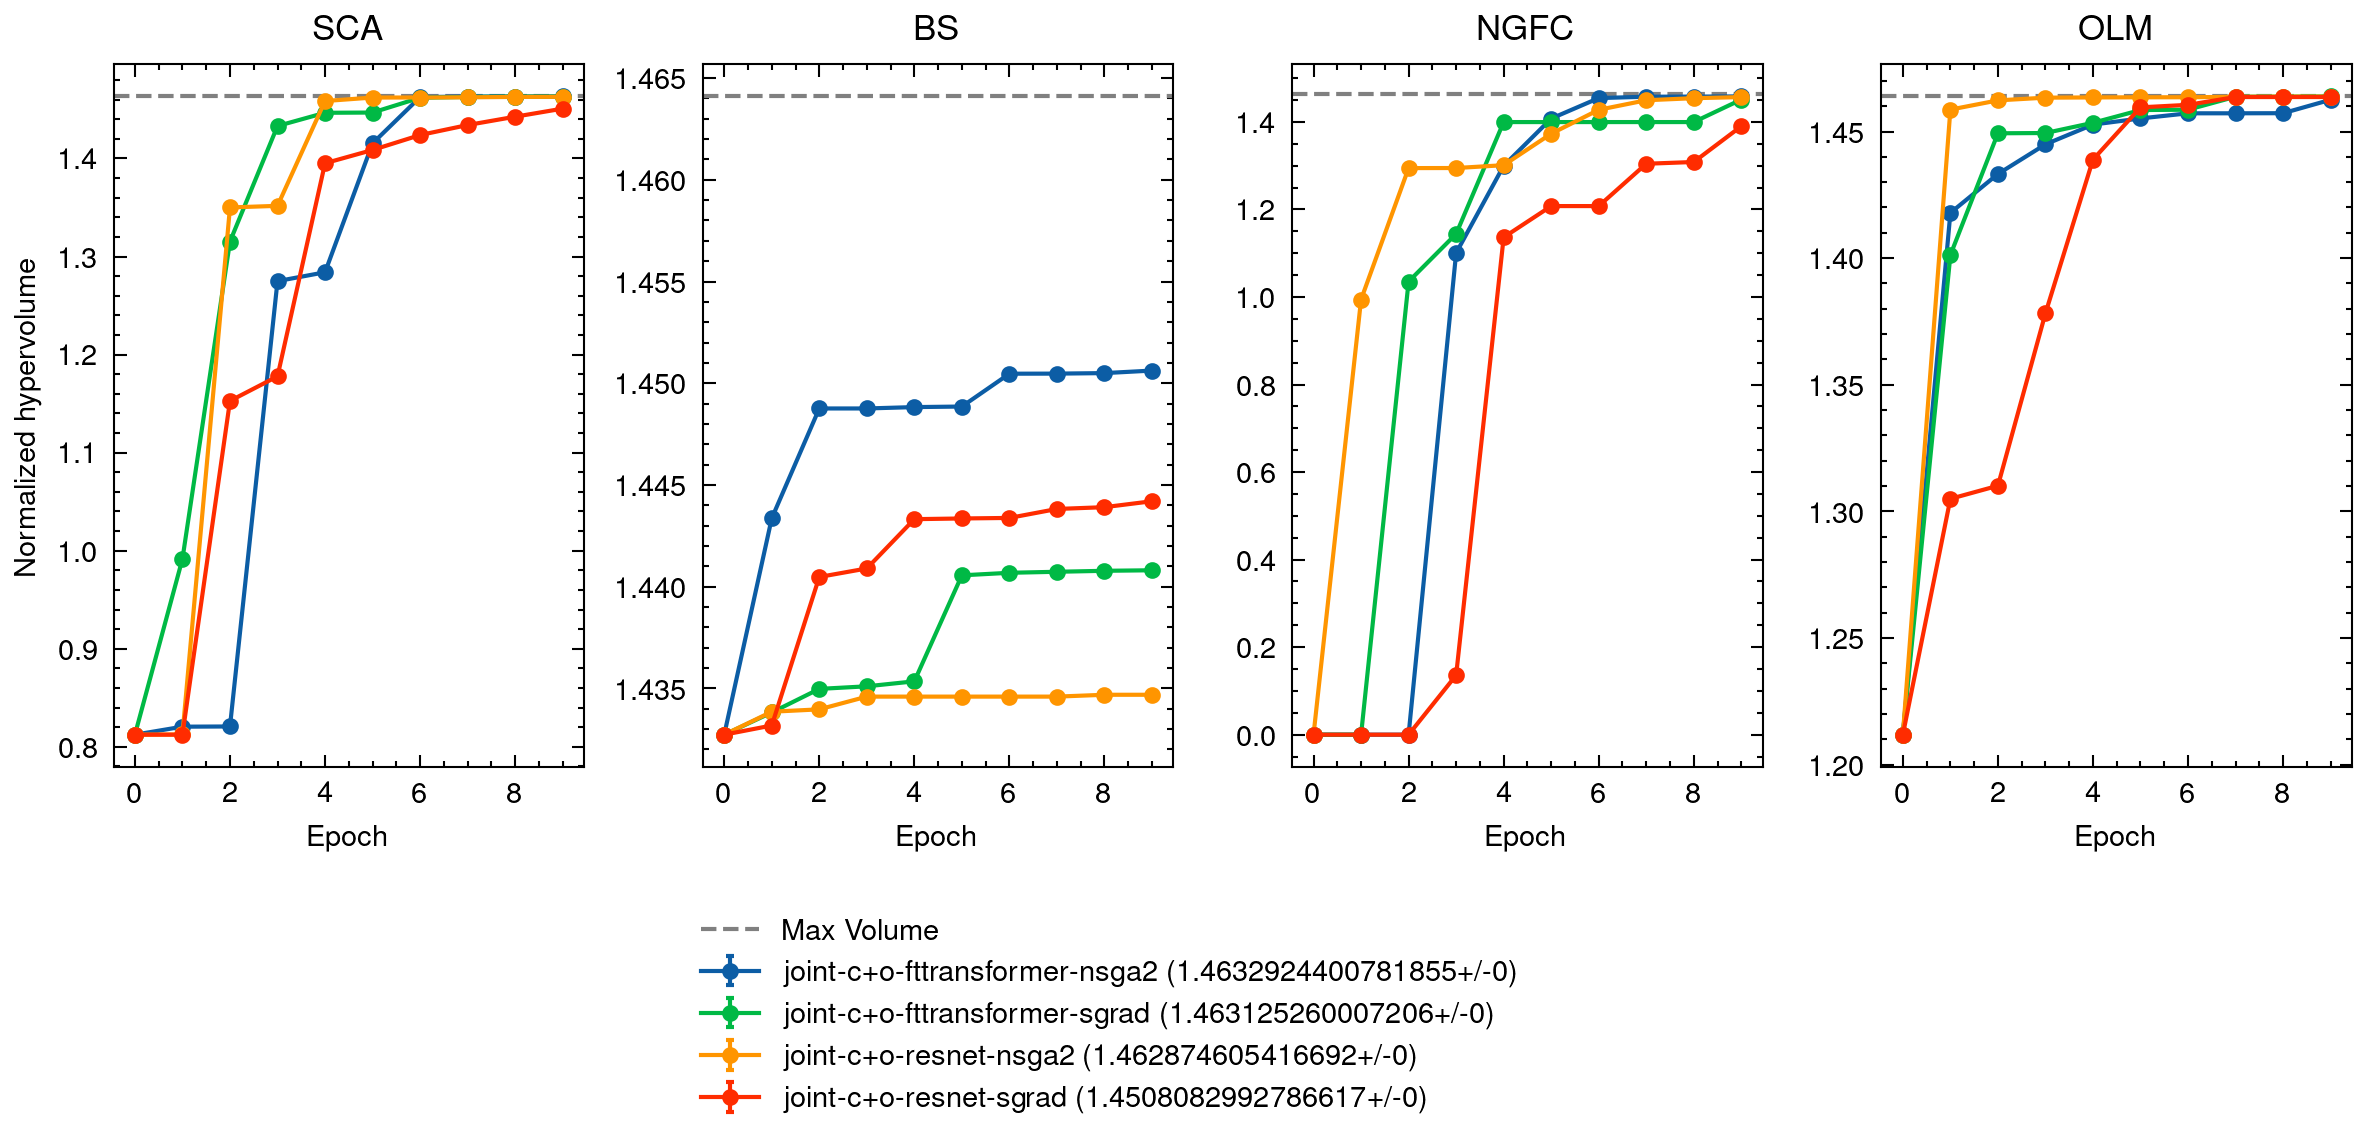

In [11]:
from uncertainties import ufloat
from scipy import stats


fig, axs = plt.subplots(1, len(sgrad_hvs), figsize=(8, 3), sharey=False)

for ax, (p, models) in zip(axs.flatten(), sgrad_hvs.items()):
    for model_name, epoch_hvs in models.items():
        x = []
        y = []
        y_err = []
        for epoch, hvs in epoch_hvs.items():
            # if epoch > 5:
            #     continue
            x.append(int(epoch))
            try:
                y.append(hvs[2]) #np.mean(hvs))
            except:
                y.append(np.nan)
            y_err.append(0) #stats.sem(hvs))

        if 'c+o' not in model_name:
            continue
        

        ax.errorbar(x, y, yerr=y_err, label=model_name + f" ({ufloat(y[-1], y_err[-1])})", fmt="-o", capsize=1)
    
    # ax.axhline(y=nos_mean, color="red", linestyle=":", label=f"NoS ({ufloat(nos_mean, nos_err)})")
    # ax.fill_between(x, [nos_mean - nos_err] * len(x), [nos_mean + nos_err] * len(x), color="red", alpha=0.1)
    #if model_name == 'baseline'

    # ax.set_xscale('log')
    # ax.set_yscale('log')
    ax.set_xlabel("Epoch")
    ax.axhline(y=1.1**4, color="grey", linestyle="--", label="Max Volume")
    #ax.set_ylim(0, 1.1**4 * 1.05)
    ax.set_title(p)
    
    #ax.legend(loc='best')

axs[0].set_ylabel("Normalized hypervolume")

handles, labels = axs[0].get_legend_handles_labels()
fig.legend(handles, labels, #ncol=len(labels), 
           bbox_to_anchor=(0.65, -0.01))
plt.tight_layout()
plt.show()